In [ ]:
# import shutil
# import os

# folder_path = 'idata'

# if os.path.exists(folder_path):
#     shutil.rmtree(folder_path)
#     print(f"{folder_path} has been deleted.")
# else:
#     print(f"{folder_path} does not exist.")


idata has been deleted.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/drive/MyDrive/Colab Notebooks/image/Aluto_dataset.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
import os
base_dir = '/content/Aluto_dataset'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'valid')

# Directory with our training potato pictures
train_potato_dir = os.path.join(train_dir, 'potato_early')

# Directory with our training tomato pictures
train_tomato_dir = os.path.join(train_dir, 'tomato_early')

# Directory with our validation potato pictures
validation_potato_dir = os.path.join(validation_dir, 'potato_early')

# Directory with our validation tomato pictures
validation_tomato_dir = os.path.join(validation_dir, 'tomato_early')

In [ ]:
train_potato_fnames = os.listdir(train_potato_dir)
train_potato_fnames.sort()
print(train_potato_fnames[:10])

train_tomato_fnames = os.listdir(train_tomato_dir)
train_tomato_fnames.sort()
print(train_tomato_fnames[:10])

['potato_early_1000_ccrp_1.JPG', 'potato_early_1000_ccrp_2.JPG', 'potato_early_1000_ccrp_3.JPG', 'potato_early_1000_ccrp_4.JPG', 'potato_early_1000_gblr_1.JPG', 'potato_early_1000_gblr_2.JPG', 'potato_early_1000_gblr_3.JPG', 'potato_early_1000_gblr_4.JPG', 'potato_early_1000_rrot_1.JPG', 'potato_early_1001_ccrp_1.JPG']
['tomato_early_100.JPG', 'tomato_early_1000.JPG', 'tomato_early_1001_ccrp_1.JPG', 'tomato_early_1001_ccrp_2.JPG', 'tomato_early_1001_ccrp_3.JPG', 'tomato_early_1001_ccrp_4.JPG', 'tomato_early_1001_gblr_1.JPG', 'tomato_early_1001_gblr_2.JPG', 'tomato_early_1001_gblr_3.JPG', 'tomato_early_1001_gblr_4.JPG']


In [ ]:
print('total training potato images:', len(os.listdir(train_potato_dir)))
print('total training tomato images:', len(os.listdir(train_tomato_dir)))
print('total validation potato images:', len(os.listdir(validation_potato_dir)))
print('total validation tomato images:', len(os.listdir(validation_tomato_dir)))

total training potato images: 1998
total training tomato images: 1998
total validation potato images: 221
total validation tomato images: 221


In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Parameters for our graph; we'll output images in a 4x4 configuration
nrows = 4
ncols = 4

# Index for iterating over images
pic_index = 0

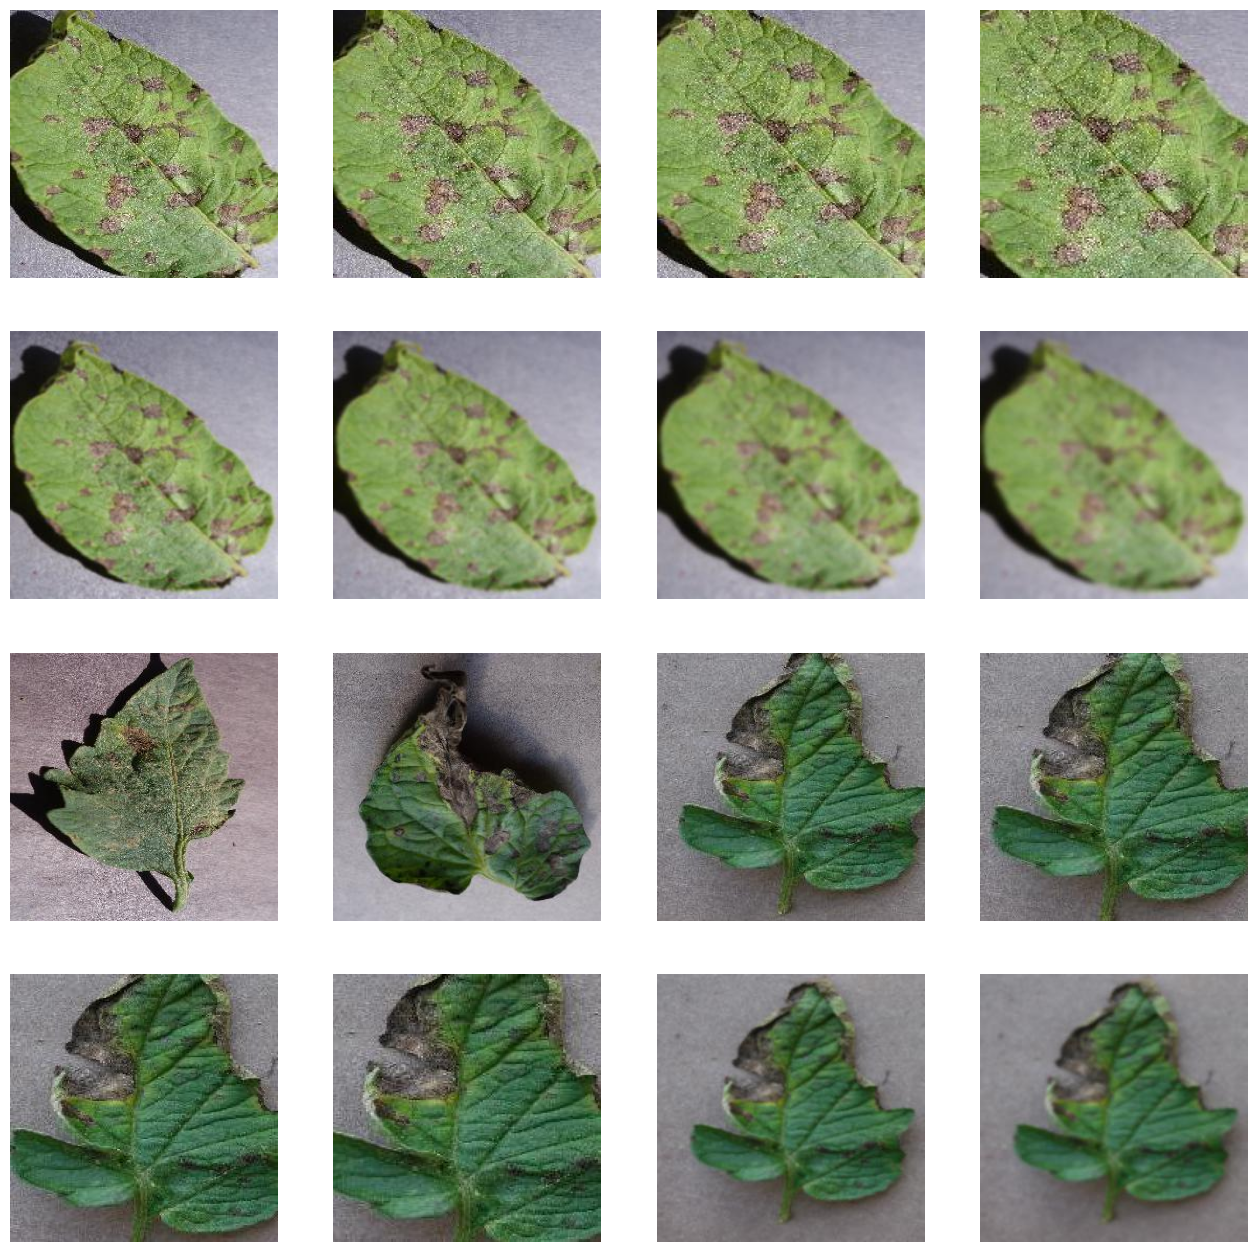

In [ ]:
# Set up matplotlib fig, and size it to fit 4x4 pics
fig = plt.gcf()
fig.set_size_inches(ncols * 4, nrows * 4)

pic_index += 8
next_potato_pix = [os.path.join(train_potato_dir, fname)
                for fname in train_potato_fnames[pic_index-8:pic_index]]
next_tomato_pix = [os.path.join(train_tomato_dir, fname)
                for fname in train_tomato_fnames[pic_index-8:pic_index]]

for i, img_path in enumerate(next_potato_pix+next_tomato_pix):
  # Set up subplot; subplot indices start at 1
  sp = plt.subplot(nrows, ncols, i + 1)
  sp.axis('Off') # Don't show axes (or gridlines)

  img = mpimg.imread(img_path)
  plt.imshow(img)

plt.show()


In [ ]:
from tensorflow.keras import layers
from tensorflow.keras import Model

In [ ]:
# Our input feature map is 150x150x3: 150x150 for the image pixels, and 3 for
# the three color channels: R, G, and B
img_input = layers.Input(shape=(150, 150, 3))

# First convolution extracts 16 filters that are 3x3
# Convolution is followed by max-pooling layer with a 2x2 window
x = layers.Conv2D(16, 3, activation='relu')(img_input)
x = layers.MaxPooling2D(2)(x)

# Second convolution extracts 32 filters that are 3x3
# Convolution is followed by max-pooling layer with a 2x2 window
x = layers.Conv2D(32, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)

# Third convolution extracts 64 filters that are 3x3
# Convolution is followed by max-pooling layer with a 2x2 window
x = layers.Conv2D(64, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)

In [ ]:
# Flatten feature map to a 1-dim tensor so we can add fully connected layers
x = layers.Flatten()(x)

# Create a fully connected layer with ReLU activation and 512 hidden units
x = layers.Dense(512, activation='relu')(x)

# Create output layer with a single node and sigmoid activation
output = layers.Dense(1, activation='sigmoid')(x)

# Create model:
# input = input feature map
# output = input feature map + stacked convolution/maxpooling layers + fully
# connected layer + sigmoid output layer
model = Model(img_input, output)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,470,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,494,561 (36.22 MB)

 Trainable params: 9,494,561 (36.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import RMSprop

model.compile(loss='binary_crossentropy',
              optimizer=RMSprop(learning_rate=0.001),
              metrics=['acc'])

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# All images will be rescaled by 1./255
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

# Flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow_from_directory(
        train_dir,  # This is the source directory for training images
        target_size=(150, 150),  # All images will be resized to 150x150
        batch_size=20,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='binary')

# Flow validation images in batches of 20 using val_datagen generator
validation_generator = val_datagen.flow_from_directory(
        validation_dir,
        target_size=(150, 150),
        batch_size=20,
        class_mode='binary')

Found 3996 images belonging to 2 classes.
Found 442 images belonging to 2 classes.


In [ ]:
history = model.fit(
      train_generator,
      steps_per_epoch=3996,  # 3996 images = batch_size * steps
      epochs=15,
      validation_data=validation_generator,
      validation_steps=442,  # 442 images = batch_size * steps
      verbose=1)

Epoch 1/15
 200/3996 ━━━━━━━━━━━━━━━━━━━━ 39:58 632ms/step - acc: 0.9757 - loss: 0.0793

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


3996/3996 ━━━━━━━━━━━━━━━━━━━━ 130s 32ms/step - acc: 0.9745 - loss: 0.0765 - val_acc: 0.9389 - val_loss: 0.1949
Epoch 2/15
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 140s 35ms/step - acc: 0.9801 - loss: 0.0599 - val_acc: 0.9774 - val_loss: 0.0560
Epoch 3/15
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 132s 33ms/step - acc: 0.9869 - loss: 0.0368 - val_acc: 0.9570 - val_loss: 0.1769
Epoch 4/15
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 141s 33ms/step - acc: 0.9898 - loss: 0.0330 - val_acc: 0.9864 - val_loss: 0.0661
Epoch 5/15
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 142s 32ms/step - acc: 0.9945 - loss: 0.0175 - val_acc: 0.9887 - val_loss: 0.0589
Epoch 6/15
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 133s 33ms/step - acc: 0.9946 - loss: 0.0231 - val_acc: 0.9796 - val_loss: 0.0662
Epoch 7/15
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 140s 35ms/step - acc: 0.9947 - loss: 0.0203 - val_acc: 0.9842 - val_loss: 0.0675
Epoch 8/15
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 133s 33ms/step - acc: 0.9944 - loss: 0.0235 - val_acc: 0.9887 - val_loss: 0.0602
Epoch 9/15
3996/3996 ━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 601ms/step


<ipython-input-26-1fdb1782c83c>:43: RuntimeWarning: invalid value encountered in divide
  x /= x.std()
<ipython-input-26-1fdb1782c83c>:46: RuntimeWarning: invalid value encountered in cast
  x = np.clip(x, 0, 255).astype('uint8')


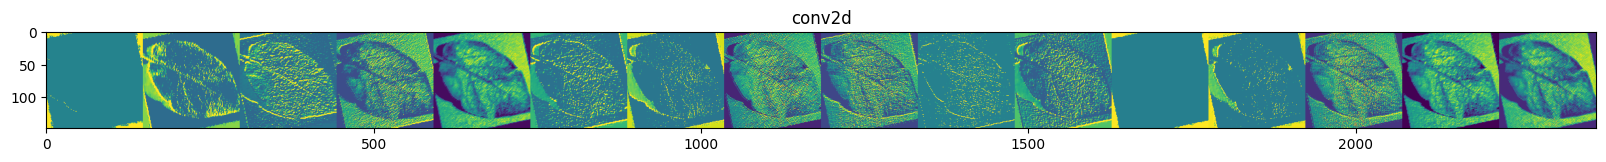

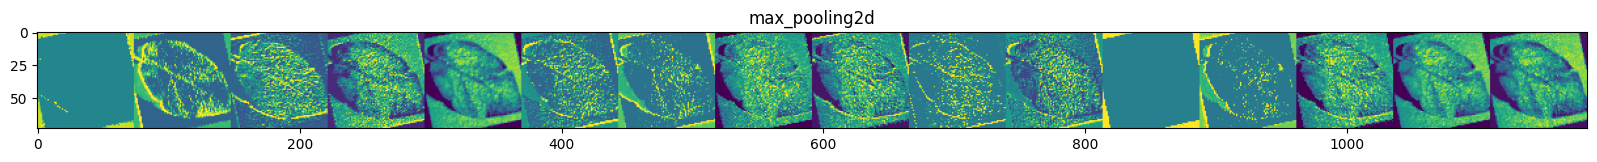

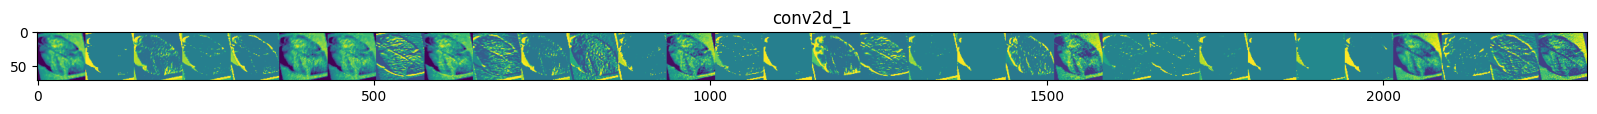

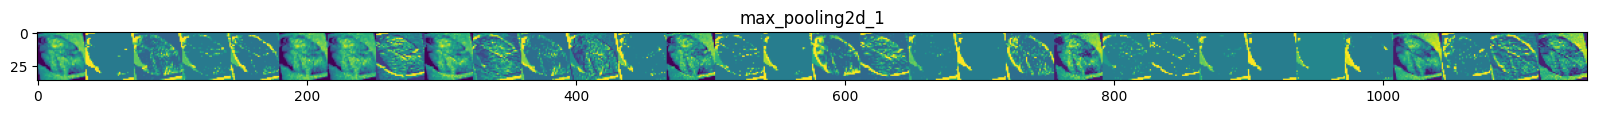

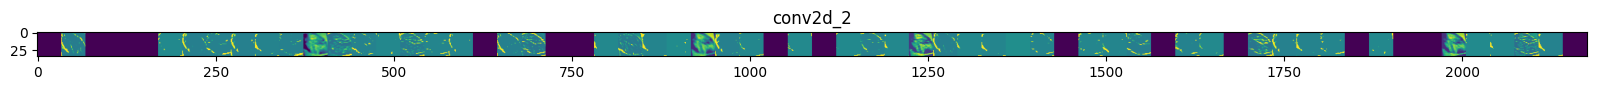

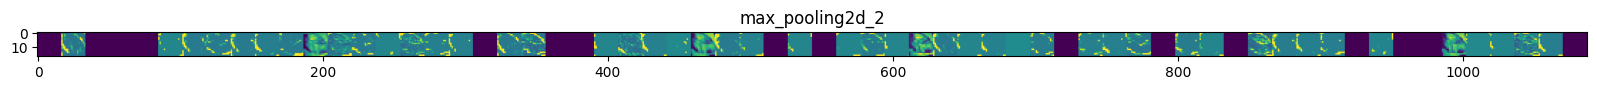

In [ ]:
import numpy as np
import random
from tensorflow.keras.preprocessing.image import img_to_array, load_img

# Let's define a new Model that will take an image as input, and will output
# intermediate representations for all layers in the previous model after
# the first.
successive_outputs = [layer.output for layer in model.layers[1:]]
visualization_model = Model(img_input, successive_outputs)

# Let's prepare a random input image of a cat or dog from the training set.
potato_img_files = [os.path.join(train_potato_dir, f) for f in train_potato_fnames]
tomato_img_files = [os.path.join(train_tomato_dir, f) for f in train_tomato_fnames]
img_path = random.choice(potato_img_files + tomato_img_files)

img = load_img(img_path, target_size=(150, 150))  # this is a PIL image
x = img_to_array(img)  # Numpy array with shape (150, 150, 3)
x = x.reshape((1,) + x.shape)  # Numpy array with shape (1, 150, 150, 3)

# Rescale by 1/255
x /= 255

# Let's run our image through our network, thus obtaining all
# intermediate representations for this image.
successive_feature_maps = visualization_model.predict(x)

# These are the names of the layers, so can have them as part of our plot
layer_names = [layer.name for layer in model.layers[1:]]

# Now let's display our representations
for layer_name, feature_map in zip(layer_names, successive_feature_maps):
  if len(feature_map.shape) == 4:
    # Just do this for the conv / maxpool layers, not the fully-connected layers
    n_features = feature_map.shape[-1]  # number of features in feature map
    # The feature map has shape (1, size, size, n_features)
    size = feature_map.shape[1]
    # We will tile our images in this matrix
    display_grid = np.zeros((size, size * n_features))
    for i in range(n_features):
      # Postprocess the feature to make it visually palatable
      x = feature_map[0, :, :, i]
      x -= x.mean()
      x /= x.std()
      x *= 64
      x += 128
      x = np.clip(x, 0, 255).astype('uint8')
      # We'll tile each filter into this big horizontal grid
      display_grid[:, i * size : (i + 1) * size] = x
    # Display the grid
    scale = 20. / n_features
    plt.figure(figsize=(scale * n_features, scale))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')

Text(0.5, 1.0, 'Training and validation loss')

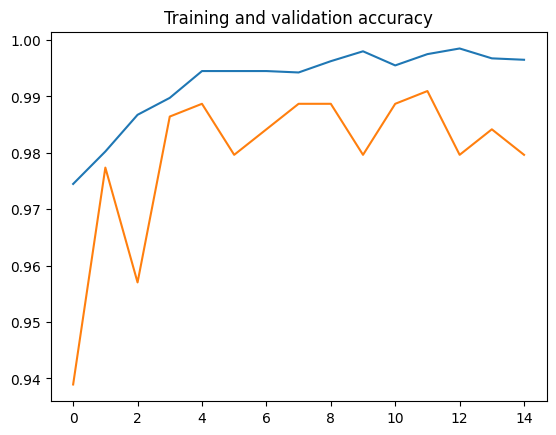

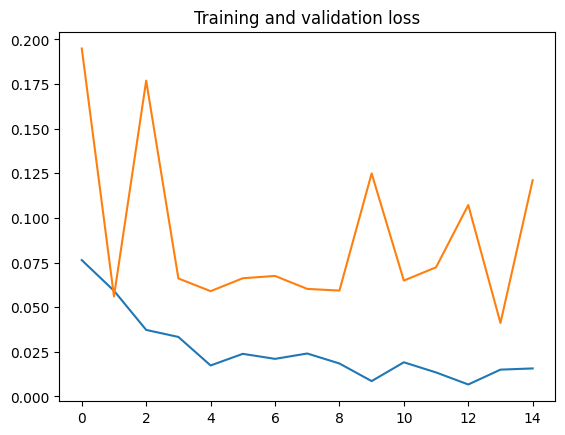

In [ ]:
# Retrieve a list of accuracy results on training and validation data
# sets for each training epoch
acc = history.history['acc']
val_acc = history.history['val_acc']

# Retrieve a list of list results on training and validation data
# sets for each training epoch
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get number of epochs
epochs = range(len(acc))

# Plot training and validation accuracy per epoch
plt.plot(epochs, acc)
plt.plot(epochs, val_acc)
plt.title('Training and validation accuracy')

plt.figure()

# Plot training and validation loss per epoch
plt.plot(epochs, loss)
plt.plot(epochs, val_loss)
plt.title('Training and validation loss')

In [ ]:
model.save("Tomalu.keras")

In [ ]:
import tensorflow as tf
new_model = tf.keras.models.load_model('Tomalu.keras')

In [ ]:
# prompt: write a function to see test image result prediction from new_model

# Define a function to predict the class of a new image
def predict_image_class(image_path):
    # Load and preprocess the image
    img = load_img(image_path, target_size=(150, 150))
    x = img_to_array(img)
    x = x.reshape((1,) + x.shape)
    x /= 255

    # Make a prediction using the loaded model
    prediction = new_model.predict(x)

    # Interpret the prediction
    if prediction[0][0] >= 0.5:
        predicted_class = 'Tomato'
    else:
        predicted_class = 'Potato'

    return predicted_class

# Example usage
# Replace 'path/to/your/test/image.jpg' with the actual path
test_image_path = '/content/Aluto_dataset/test/potato_early_120.JPG'
predicted_class = predict_image_class(test_image_path)
print(f"The predicted class for {test_image_path} is: {predicted_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
The predicted class for /content/Aluto_dataset/test/potato_early_120.JPG is: Potato


In [ ]:
!pip install rembg onnxruntime
from rembg import remove
from PIL import Image
import io

# Input and Output Paths
input_path = "/content/001.jpeg"  # Uploaded image
output_path = "/content/007.png"

# Load the image as bytes
with open(input_path, "rb") as inp_file:
    input_image = inp_file.read()

# Remove the background
output_image = remove(input_image)

# Save the output image
with open(output_path, "wb") as out_file:
    out_file.write(output_image)

# Display the result
Image.open(io.BytesIO(output_image)).show()

print("✅ Background removed and saved as '006.png'")


✅ Background removed and saved as '006.png'
